# Import libraries

In [1]:
#from matplotlib.pyplot import * 
#from numpy import *
import pynested_fit as pynf
import os

%matplotlib inline
#%matplotlib widget
#%matplotlib notebook

In [2]:
pynf.__version__

'5.6.4'

In [3]:
# Define the present path as root path
root_path = os.getcwd()
print(root_path)

path = root_path+'/res_1gauss_bg'
print(path)

/home/dph/nested_fit/examples/jupyter_notebooks
/home/dph/nested_fit/examples/jupyter_notebooks/res_1gauss_bg


# Run the code in a specific directory

In [4]:
# Go to a define analysis
os.chdir(path)

### Example of use of internal or already defined internal function

In [5]:
#### Define inputs using a "latex" function
conf = pynf.Configurator(
    datafiles=['he-histo.dat'], # Name of the data file
    filefmt='.tsv',             # Format of file (here for tab and space separated)
    specstr='x,c',              # Datafile layout (here ch. and counts in ch.)
    expressions=[               # Function expression in latex form
        r'gauss_bg(x, A_1, x_1, s, b_g) = \texttt{GAUSS_IF}(x, x_1, A_1, s) + b_g'], 
    params={                    # function expression in latex form
        'b_g': {'value': 0.01,  'step': -1, 'min': 0,   'max': 0.3 },
        'x_1': {'value': 454.6, 'step': -1, 'min': 300, 'max': 600 },
        'A_1': {'value': 300,   'step': -1, 'min': 0,   'max': 500},
        's':   {'value': 20,    'step': -1, 'min': 10,  'max': 30}
    },
    data={'xmin': 250, 'xmax': 650},  # Boundaries of data
    livepoints=1000,                  # Number of live points
    search_method='SLICE_SAMPLING',   # Search method
    search_params=(0.5, 3),           # Parameters of chosen method
    search_maxsteps=100000,           # Max steps of nested sampling
    conv_accuracy=1.E-05,             # Evidence final accuracy
    cluster_enable=False,             # clustering recognition on/off
    # cluster_method='k',             # method used
    # cluster_parameter1=0.5,         # method parameter 1 (if needed)
    # cluster_parameter2=0.2,         # method parameter 1 (if needed)
)

### Example of latex function (change from markdown to a code input and run it)

#### Define inputs using a "latex" function
conf = pynf.Configurator(
    datafiles=['he-histo.dat'], # Name of the data file
    filefmt='.tsv',             # Format of file (here for tab and space separated)
    specstr='x,c',              # Datafile layout (here ch. and counts in ch.)
    expressions=[               # Function expression in latex form
        r'gauss_bg(x, A_1, x_1, s, b_g) = A_1 / (s \sqrt{2\pi}) \exp{-(x-x_1)^2/(2s^2)} + b_g'], 
    params={                    # function expression in latex form
        'b_g': {'value': 0.01,  'step': -1, 'min': 0,   'max': 0.3 },
        'x_1': {'value': 454.6, 'step': -1, 'min': 300, 'max': 600 },
        'A_1': {'value': 300,   'step': -1, 'min': 0,   'max': 500},
        's':   {'value': 20,    'step': -1, 'min': 10,  'max': 30}
    },
    data={'xmin': 250, 'xmax': 650},  # Boundaries of data
    livepoints=1000,                  # Number of live points
    search_method='SLICE_SAMPLING',   # Search method
    search_params=(0.5, 3),           # Parameters of chosen method
    search_maxsteps=100000,           # Max steps of nested sampling
    conv_accuracy=1.E-05,             # Evidence final accuracy
    cluster_enable=False,             # clustering recognition on/off
    # cluster_method='k',             # method used
    # cluster_parameter1=0.5,         # method parameter 1 (if needed)
    # cluster_parameter2=0.2,         # method parameter 1 (if needed)
)

### Example of legacy function use from USERFCN.f (change from markdown to a code input and run it)

#### Define inputs using a "legacy" function
conf = pynf.Configurator(
    datafiles=['he-histo.dat'], # Name of the data file
    filefmt='.tsv',             # Format of file (here for tab and space separated)
    specstr='x,c',              # Datafile layout (here ch. and counts in ch.)
    expressions=['GAUSS_BG'],
    params={                    # Function expression from legacy
        'b_g': {'value': 0.01,  'step': -1, 'min': 0, 'max': 0.3 ,   'npar': 1},
        'x_1': {'value': 454.6, 'step': -1, 'min': 300, 'max': 600 , 'npar': 2},
        'A_1': {'value': 300,   'step': -1, 'min': 0, 'max': 500 ,   'npar': 3},
        's':   {'value': 20,    'step': -1, 'min': 10, 'max': 30 ,   'npar': 4}
    },
    data={'xmin': 250, 'xmax': 650},  # Boundaries of data
    livepoints=1000,                  # Number of live points
    search_method='SLICE_SAMPLING',   # Search method
    search_params=(0.5, 3),           # Parameters of chosen method
    search_maxsteps=100000,           # Max steps of nested sampling
    conv_accuracy=1.E-05,             # Evidence final accuracy
    # num_tries=1,                    # Number of run of the same analysis for error estimation
    cluster_enable=False,             # clustering recognition on/off
    # cluster_method='k',             # method used
    # cluster_parameter1=0.5,         # method parameter 1 (if needed)
    # cluster_parameter2=0.2,         # method parameter 1 (if needed)
)

In [6]:
# Run the code

# For visualising the progress of the execution use this command
out = conf.sample(output_mode='live')

# For visualising the progress graphycally (not working in Google Colab), use
# out = conf.sample(output_mode='full')

# If nothing shows, use simply the command (symlink to created or version to be used)
# Create the command to run nested fit in case of need
# run_nested_fit = os.system('nested_fit'+pynf.__version__)
# run_nested_fit

# For silently running the code and save the raw output in a dictionnary, use this command
# out = conf.sample(output_mode='none')

========= Parsing result =========
     Latex input: \texttt{GAUSS_IF}(x, x_1, A_1, s) + b_g
Infix expression: GAUSS_IF(x,x1,A1,s)+bg
      Parameters: A_1, b_g, s, x_1
| N. try:  1 | N. step:        100 | Min. loglike:   -1504.256542267180976 | Evidence:   -1511.815907246836332 | Ev. step:   -1511.826479636527210 | Ev. pres. acc.:  1.1761544E+03 | Typical eff.: 0.7500 |                
| N. try:  1 | N. step:        200 | Min. loglike:   -1333.601946530905934 | Evidence:   -1341.928768711016346 | Ev. step:   -1342.057445172534926 | Ev. pres. acc.:  1.0061673E+03 | Typical eff.: 0.6000 |                
| N. try:  1 | N. step:        300 | Min. loglike:   -1242.911258071407246 | Evidence:   -1249.382122482039676 | Ev. step:   -1250.313329204316915 | Ev. pres. acc.:  9.1352065E+02 | Typical eff.: 1.0000 |                
| N. try:  1 | N. step:        400 | Min. loglike:   -1152.277489751021903 | Evidence:   -1159.466470218469794 | Ev. step:   -1160.102914764124080 | Ev. pres. acc.:  8.

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



            
| N. try:  1 | N. step:       2300 | Min. loglike:    -467.796201976928785 | Evidence:    -475.069803577876996 | Ev. step:    -477.059241835564990 | Ev. pres. acc.:  1.4347545E+02 | Typical eff.: 1.0000 |                
| N. try:  1 | N. step:       2400 | Min. loglike:    -453.396211175891153 | Evidence:    -461.135916758042242 | Ev. step:    -463.474592929981043 | Ev. pres. acc.:  1.2944156E+02 | Typical eff.: 0.6000 |                
| N. try:  1 | N. step:       2500 | Min. loglike:    -440.832394155801239 | Evidence:    -447.817954973559154 | Ev. step:    -450.293538603686386 | Ev. pres. acc.:  1.1602360E+02 | Typical eff.: 0.7500 |                
| N. try:  1 | N. step:       2600 | Min. loglike:    -430.654079813482554 | Evidence:    -437.989909495315146 | Ev. step:    -440.163502856555738 | Ev. pres. acc.:  1.0609556E+02 | Typical eff.: 1.0000 |                
| N. try:  1 | N. step:       2700 | Min. loglike:    -422.204398998004422 | Evidence:    -429.35765023

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



glike:    -362.562543729449317 | Evidence:    -369.502509606195588 | Ev. step:    -373.573498818342216 | Ev. pres. acc.:  3.6108157E+01 | Typical eff.: 1.0000 |                
| N. try:  1 | N. step:       4200 | Min. loglike:    -360.581210833808427 | Evidence:    -367.638204399879498 | Ev. step:    -371.700938704506427 | Ev. pres. acc.:  3.4288529E+01 | Typical eff.: 1.0000 |                
| N. try:  1 | N. step:       4300 | Min. loglike:    -358.659953537448473 | Evidence:    -365.937859137328132 | Ev. step:    -369.883050988929767 | Ev. pres. acc.:  3.2862137E+01 | Typical eff.: 1.0000 |                
| N. try:  1 | N. step:       4400 | Min. loglike:    -356.746561134769536 | Evidence:    -364.005235988541699 | Ev. step:    -368.055485233199590 | Ev. pres. acc.:  3.0829514E+01 | Typical eff.: 1.0000 |                
| N. try:  1 | N. step:       4500 | Min. loglike:    -355.168117541186461 | Evidence:    -362.336765959102593 | Ev. step:    -366.576090956804478 | Ev. pres. a

...

ical eff.: 1.0000 |                
| N. try:  1 | N. step:      18300 | Min. loglike:    -328.251890156295531 | Evidence:    -338.287857750092144 | Ev. step:    -353.459670717449399 | Ev. pres. acc.:  2.6305649E-04 | Typical eff.: 1.0000 |                
| N. try:  1 | N. step:      18400 | Min. loglike:    -328.250570911645241 | Evidence:    -338.287833230076558 | Ev. step:    -353.558335089609045 | Ev. pres. acc.:  2.3812233E-04 | Typical eff.: 1.0000 |                
| N. try:  1 | N. step:      18500 | Min. loglike:    -328.249515839377864 | Evidence:    -338.287811019233402 | Ev. step:    -353.657279182228365 | Ev. pres. acc.:  2.1545965E-04 | Typical eff.: 1.0000 |                
| N. try:  1 | N. step:      18600 | Min. loglike:    -328.248421734814087 | Evidence:    -338.287790900188895 | Ev. step:    -353.756177674514959 | Ev. pres. acc.:  1.9495403E-04 | Typical eff.: 1.0000 |                
| N. try:  1 | N. step:      18700 | Min. loglike:    -328.247694566339192 | Evi

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



N. try:  1 | N. step:      20100 | Min. loglike:    -328.238334469883966 | Evidence:    -338.287641590017188 | Ev. step:    -355.246092701288433 | Ev. pres. acc.:  4.3533009E-05 | Typical eff.: 1.0000 |                
| N. try:  1 | N. step:      20200 | Min. loglike:    -328.237917721428175 | Evidence:    -338.287637484471702 | Ev. step:    -355.345675201985557 | Ev. pres. acc.:  3.9390215E-05 | Typical eff.: 1.0000 |                
| N. try:  1 | N. step:      20300 | Min. loglike:    -328.237552783687931 | Evidence:    -338.287633768127705 | Ev. step:    -355.445310839376248 | Ev. pres. acc.:  3.5641675E-05 | Typical eff.: 0.7500 |                
| N. try:  1 | N. step:      20400 | Min. loglike:    -328.237119528056382 | Evidence:    -338.287630404132926 | Ev. step:    -355.544878476759209 | Ev. pres. acc.:  3.2249868E-05 | Typical eff.: 1.0000 |                
| N. try:  1 | N. step:      20500 | Min. loglike:    -328.236753025235885 | Evidence:    -338.287627359042745 | Ev. s

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



        -338.28759832256230     
 Evidence estimated uncertainty (log):        8.9925079641134595E-002
 Evidence standard deviation (log):           0.0000000000000000     
 ------------------------------------------------------------------------------------------------------------------
 Max likelihood (log):  -328.22944607846449     
 Max parameter set : 
 A_1       :   299.87545774787395     
 x_1       :   454.36131037334974     
 s         :   26.186308230061371     
 b_g       :   9.7707062962468588E-002
 -------------------------------------------------------------------------------------------------------------------
 Mean value and standard deviation of the parameters
 A_1       :   300.20170143526423      +/-   18.341868925487216     
 x_1       :   454.41952747378718      +/-   1.7173540286129374     
 s         :   26.279594328309557      +/-   1.4699527895314857     
 b_g       :  0.10233146928144934      +/-   2.2439895691676259E-002
 -------------------------------------

# Visualize the results

In [7]:
# Load the nested output data
# The available parameters and other variables that can be plotted are listed
an=pynf.Analysis()

Current path =  .
Result file nf_output_energy.txt not present
 No energies data loaded
['A_1', 'x_1', 's', 'b_g']
Index(['weight', 'lnlikelihood', 'A_1', 'x_1', 's', 'b_g'], dtype='str')
Available parameters : ['weight', 'lnlikelihood', 'A_1', 'x_1', 's', 'b_g']


0 max
nf_output_data_max.dat


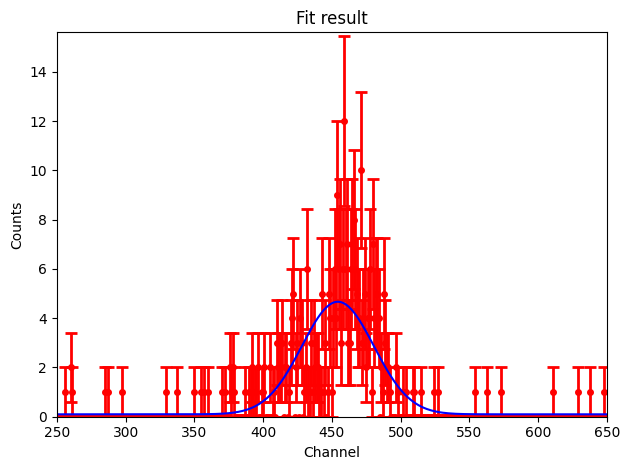

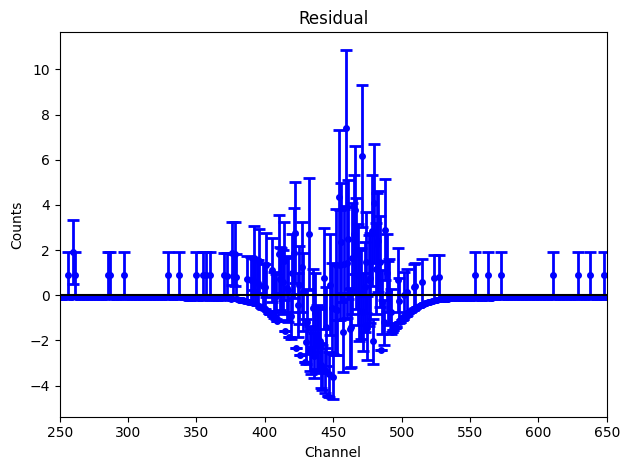

In [8]:
# Plot the data with the best fit (parameters corresponding to the maximum value of the data) and residual
# Other choices are median and mean parameters values selectable with "typeof='mean'" and "typeof='median'"
an.plot()

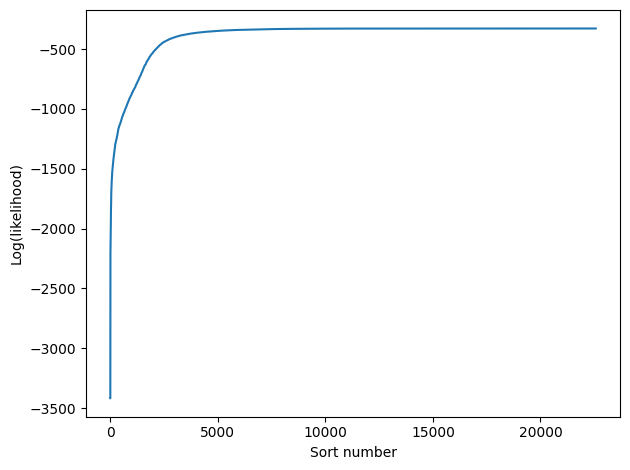

In [9]:
# Plot the likelihood sampling 
an.plot_like()

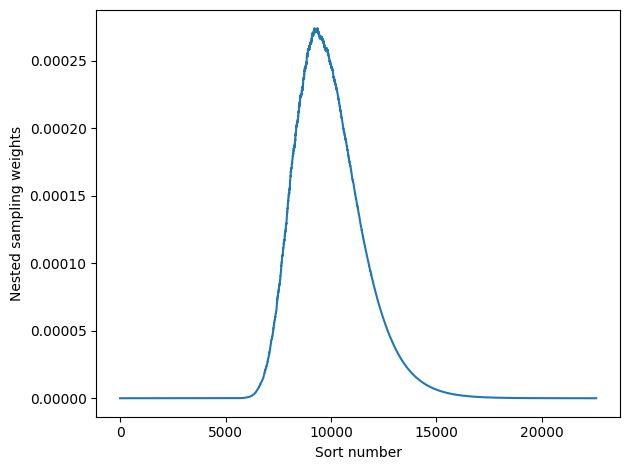

In [10]:
# Plot the weights of nested sampling corresponding to w_n = Delta X_n L_n
an.plot_weights()

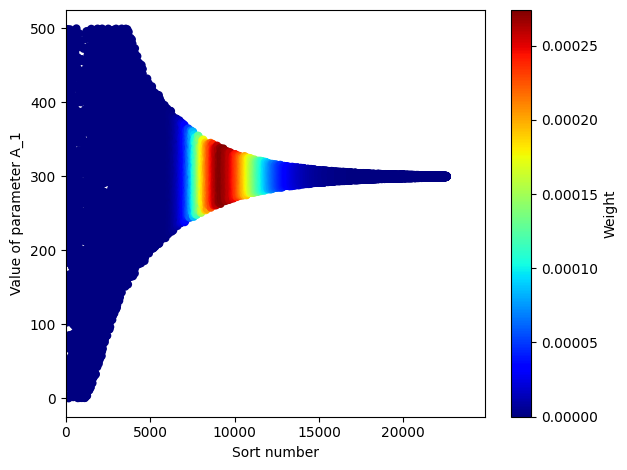

In [11]:
# Plot the parameter convergence
# Colored regions correspond to the high value of the weights
an.plot_par('A_1')

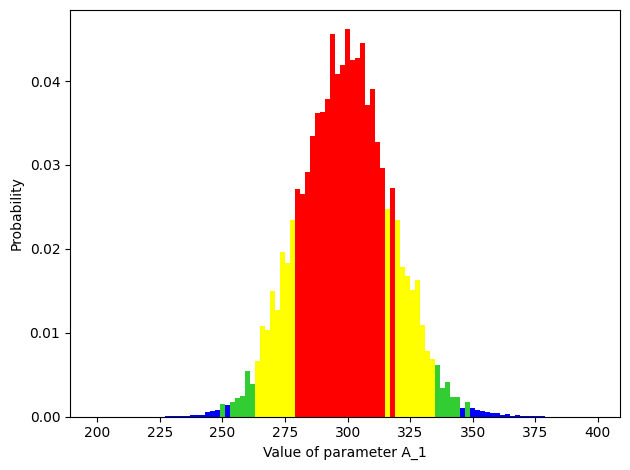

In [12]:
# Plot one parameter histogram
# Red, yellow and green region correspond to 1,2,3 sigmas
an.histo('A_1',bins=100,xmin=200,xmax=400)

/home/dph/nested_fit/venv/lib/python3.12/site-packages/anesthetic/samples.py:1403: RuntimeWarning: 24 out of 22572 samples have logL <= logL_birth,
24 of which have logL == logL_birth.
This may just indicate numerical rounding errors at the peak of the likelihood, but further investigation of the chains files is recommended.
Dropping the invalid samples.
  warnings.warn(


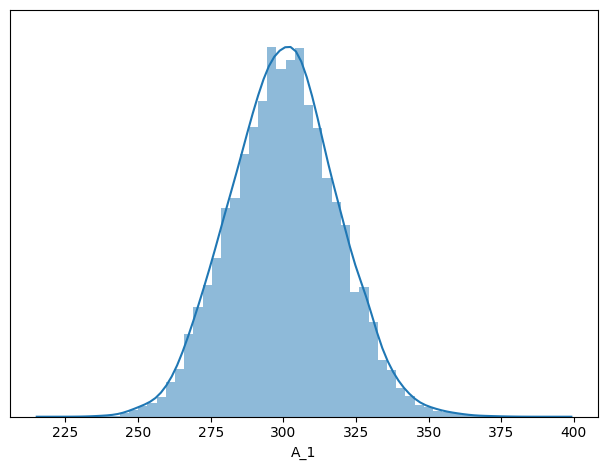

In [13]:
# Plot one parameter interpolated histogram using getdist
# Note: this is a third part function and it requires to specify the path explicitally
an.histo_interp('A_1')

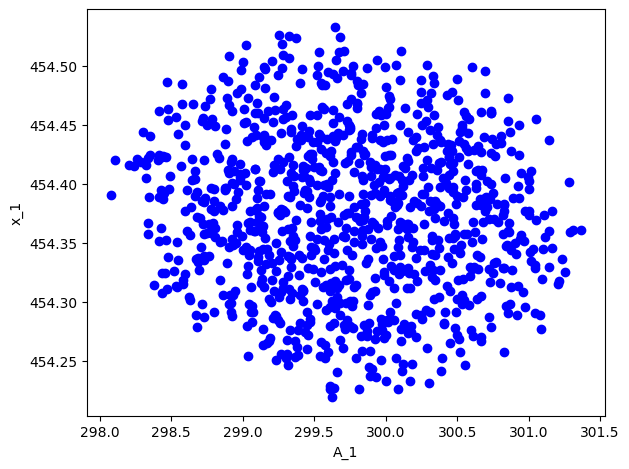

In [14]:
an.plot_live('A_1','x_1')

/home/dph/nested_fit/venv/lib/python3.12/site-packages/pynested_fit/nested_res.py:1177: RuntimeWarning: divide by zero encountered in log
  plt.imshow(log(histo2D_data68[::-1,]),interpolation='nearest',extent=extent,aspect='auto',cmap=rvb68)
/home/dph/nested_fit/venv/lib/python3.12/site-packages/pynested_fit/nested_res.py:1178: RuntimeWarning: divide by zero encountered in log
  plt.imshow(log(histo2D_data95[::-1,]),interpolation='nearest',extent=extent,aspect='auto',cmap=rvb95)
/home/dph/nested_fit/venv/lib/python3.12/site-packages/pynested_fit/nested_res.py:1179: RuntimeWarning: divide by zero encountered in log
  plt.imshow(log(histo2D_data99[::-1,]),interpolation='nearest',extent=extent,aspect='auto',cmap=rvb99)
/home/dph/nested_fit/venv/lib/python3.12/site-packages/pynested_fit/nested_res.py:1180: RuntimeWarning: divide by zero encountered in log
  plt.imshow(log(histo2D_data_rest[::-1,]),interpolation='nearest',extent=extent,aspect='auto',cmap=rvb_rest)


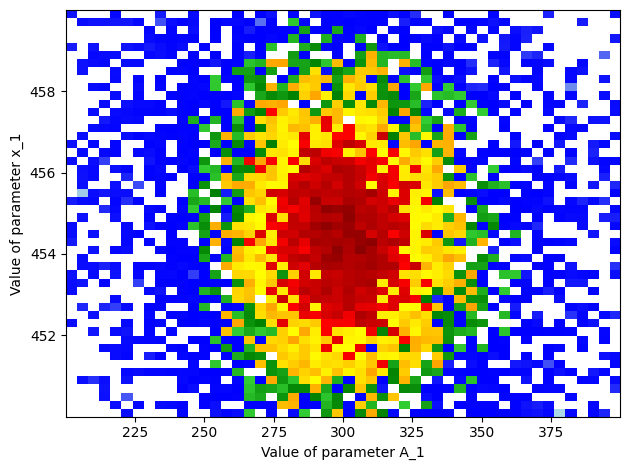

In [15]:
# Plot one parameter histogram
# Red, yellow and green region correspond to 1,2,3 sigmas
an.histo2D('A_1','x_1',bins=50,xmin=200,xmax=400,ymin=450,ymax=460)

/home/dph/nested_fit/venv/lib/python3.12/site-packages/anesthetic/samples.py:1403: RuntimeWarning: 24 out of 22572 samples have logL <= logL_birth,
24 of which have logL == logL_birth.
This may just indicate numerical rounding errors at the peak of the likelihood, but further investigation of the chains files is recommended.
Dropping the invalid samples.
  warnings.warn(


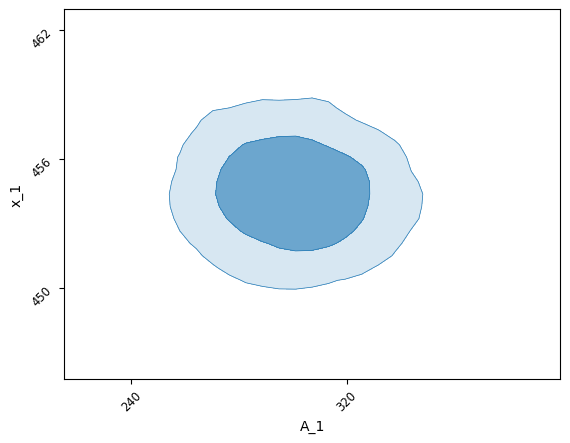

In [16]:
# Same with interpolation from getdist
# Note: this is a third part function and it requires to specify the path explicitally
an.histo2D_interp('A_1','x_1')


/home/dph/nested_fit/venv/lib/python3.12/site-packages/anesthetic/samples.py:1403: RuntimeWarning: 24 out of 22572 samples have logL <= logL_birth,
24 of which have logL == logL_birth.
This may just indicate numerical rounding errors at the peak of the likelihood, but further investigation of the chains files is recommended.
Dropping the invalid samples.
  warnings.warn(


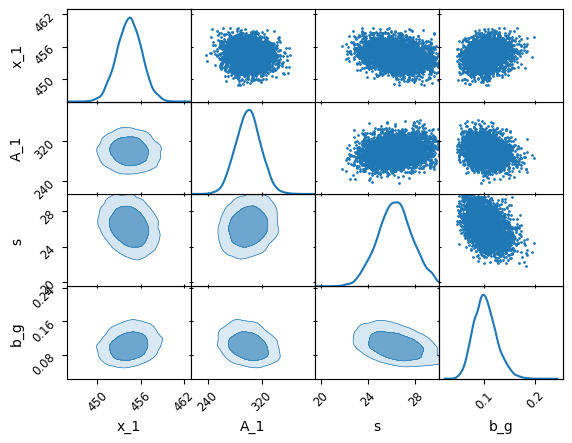

In [17]:
# Triangle plot (from anesthetic) to have a look to all parameters at the same time
an.triangle_plot(['x_1','A_1','s','b_g'])

# Extract important data and post-processing
The results can be extracted by the output of the python function: `out = conf.sample()`
Alternatively, another function can be used to read the output ASCII files (`output = an.read_output()`) or the `.json` finles

### Using the python function output

In [18]:
# Extract the raw information of evidence
out[ 'evidence']

{'stddev': 0.0, 'uncertainty': 0.0899250796411346, 'value': -338.2875983225623}

In [19]:
# Specific information of output parameters
par_name = 'x_1'
print(par_name, ' = ', out['params'][par_name][ 'mean'],' ± ', out['params'][par_name][ 'std'])

x_1  =  454.4195274737872  ±  1.7173540286129374


In [20]:
# Miscelaneous information
out['meta']

{'bayes_complexity': 3.943264591266825,
 'information': 8.0865199484644,
 'minimal_req_it': 3250,
 'ncores': 12,
 'timereal': 16.89962254399984,
 'timetotal': 157.41361099999997}

### Using the built in function 'read_output'

In [21]:
# Read the output files in a dictionnary
out = an.read_output()

# Print some results

# The evidence
print('Evidence = ', out['evidence'],'±',out['evidence_err_est'])

# The Bayesian complexity
print('Complexity = ', out['complexity'])

# Some parameter
par_name = 'x_1'
par_index = out['par_name'].index('x_1')
print(par_name, ' = ', out['mean'][par_index],' ± ', out['sd'][par_index])

Evidence =  -338.2875983225623 ± 0.0899250796411346
Complexity =  3.943264591266825
x_1  =  454.4195274737872  ±  1.7173540286129374


In [22]:
# Statistics (from anesthetic) to have a good estimation of the uncertainties (expecially for the evidence)
an.stats()

/home/dph/nested_fit/venv/lib/python3.12/site-packages/anesthetic/samples.py:1403: RuntimeWarning: 24 out of 22572 samples have logL <= logL_birth,
24 of which have logL == logL_birth.
This may just indicate numerical rounding errors at the peak of the likelihood, but further investigation of the chains files is recommended.
Dropping the invalid samples.
  warnings.warn(


logZ 	 = -338.291639 	± 0.086975
D_KL 	 = 8.093019 	± 0.083290
logL_P 	 = -330.198619 	± 0.028612
d_G 	 = 3.867073 	± 0.080838


# Combine latex functions with library functions

## Two Gaussian plus background

In [23]:
# Define a directory 
path = root_path+'/res_2gauss_bg'
# Go to a define analysis
os.chdir(path)

print(path)

/home/dph/nested_fit/examples/jupyter_notebooks/res_2gauss_bg


### Run the code

In [24]:
# Define inputs using a "latex" function
conf = pynf.Configurator(
    datafiles=['he-histo.dat'], # Name of the data file
    filefmt='.tsv',             # Format of file (here for tab and space separated)
    specstr='x,c',              # Datafile layout (here ch. and counts in ch.)
    expressions=[               # Function expression in latex form using an internal function (twice)
        r'double_gauss_bg(x, x_1, x_2, A_1, A_2, s, b_g) =' + 
        r' + \texttt{GAUSS_IF}(x, x_1, A_1, s)' +  # These additional "+" are to write in more than one line
        r' + \texttt{GAUSS_IF}(x, x_2, A_2, s) + b_g'], 
    params={                    # function expression in latex form
        'b_g': {'value': 0.01,  'step': -1, 'min': 0,   'max': 0.3 },
        'x_1': {'value': 454.6, 'step': -1, 'min': 300, 'max': 600 },
        'x_2': {'value': 454.6, 'step': -1, 'min': 300, 'max': 600 },
        'A_1': {'value': 300,   'step': -1, 'min': 0,   'max': 500},
        'A_2': {'value': 300,   'step': -1, 'min': 0,   'max': 500},
        's':   {'value': 20,    'step': -1, 'min': 10,  'max': 30}
    },
    data={'xmin': 250, 'xmax': 650},  # Boundaries of data
    livepoints=1000,                  # Number of live points
    search_method='SLICE_SAMPLING',   # Search method
    search_params=(0.5, 3),           # Parameters of chosen method
    search_maxsteps=100000,           # Max steps of nested sampling
    conv_accuracy=1.E-05,             # Evidence final accuracy
    # num_tries=4,                    # Number of run of the same analysis for error estimation
    cluster_enable=True,              # clustering recognition on/off
    # cluster_method='k',             # method used
    # cluster_parameter1=0.5,         # method parameter 1 (if needed)
    # cluster_parameter2=0.2,         # method parameter 1 (if needed)
)

In [25]:
# Run the code

out = conf.sample(output_mode='none')

### Visualize the results 

In [26]:
# Load the nested output data
# The available parameters and other variables that can be plotted are listed
an=pynf.Analysis()

Current path =  .
Result file nf_output_energy.txt not present
 No energies data loaded
['x_1', 'x_2', 'A_1', 'A_2', 's', 'b_g']
Index(['weight', 'lnlikelihood', 'x_1', 'x_2', 'A_1', 'A_2', 's', 'b_g'], dtype='str')
Available parameters : ['weight', 'lnlikelihood', 'x_1', 'x_2', 'A_1', 'A_2', 's', 'b_g']


0 max
nf_output_data_max.dat


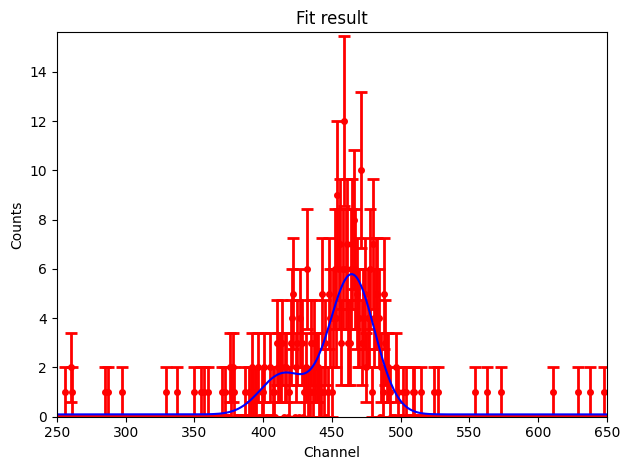

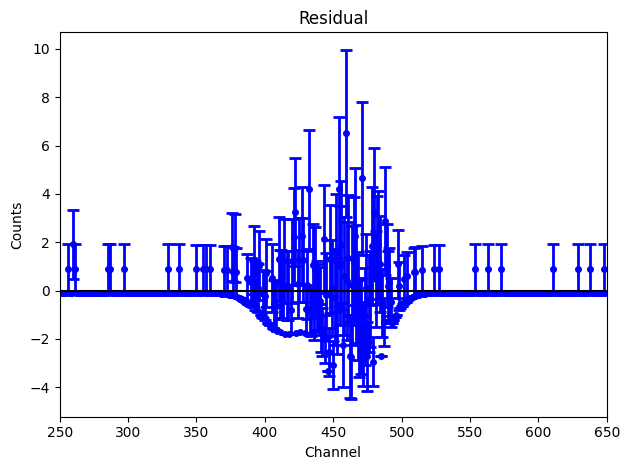

In [27]:
# Plot the data with the best fit (parameters corresponding to the maximum value of the data) and residual
# Other choices are median and mean parameters values selectable with "typeof='mean'" and "typeof='median'"
an.plot()

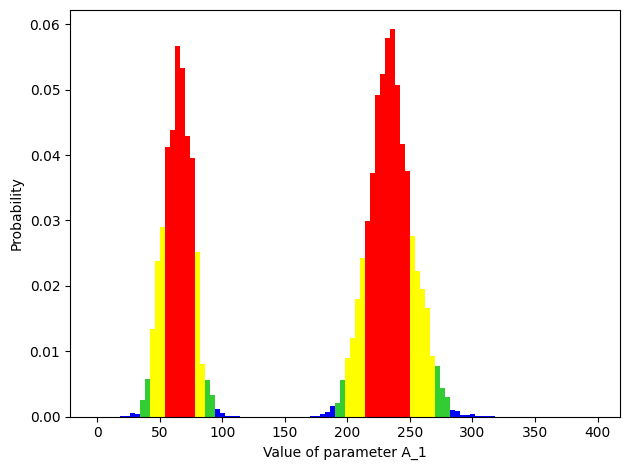

In [28]:
# Plot one parameter histogram
# Red, yellow and green region correspond to 1,2,3 sigmas
an.histo('A_1',bins=100,xmin=0,xmax=400)

/home/dph/nested_fit/venv/lib/python3.12/site-packages/pynested_fit/nested_res.py:1177: RuntimeWarning: divide by zero encountered in log
  plt.imshow(log(histo2D_data68[::-1,]),interpolation='nearest',extent=extent,aspect='auto',cmap=rvb68)
/home/dph/nested_fit/venv/lib/python3.12/site-packages/pynested_fit/nested_res.py:1178: RuntimeWarning: divide by zero encountered in log
  plt.imshow(log(histo2D_data95[::-1,]),interpolation='nearest',extent=extent,aspect='auto',cmap=rvb95)
/home/dph/nested_fit/venv/lib/python3.12/site-packages/pynested_fit/nested_res.py:1179: RuntimeWarning: divide by zero encountered in log
  plt.imshow(log(histo2D_data99[::-1,]),interpolation='nearest',extent=extent,aspect='auto',cmap=rvb99)
/home/dph/nested_fit/venv/lib/python3.12/site-packages/pynested_fit/nested_res.py:1180: RuntimeWarning: divide by zero encountered in log
  plt.imshow(log(histo2D_data_rest[::-1,]),interpolation='nearest',extent=extent,aspect='auto',cmap=rvb_rest)


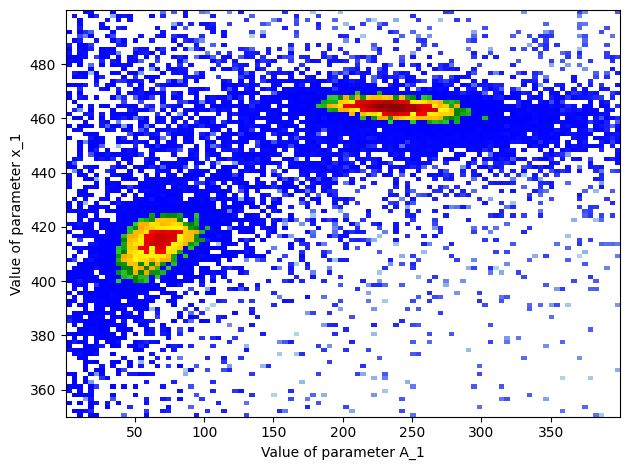

In [29]:
# Plot one parameter histogram
# Red, yellow and green region correspond to 1,2,3 sigmas
an.histo2D('A_1','x_1',bins=100,xmin=0,xmax=400,ymin=350,ymax=500)

/home/dph/nested_fit/venv/lib/python3.12/site-packages/anesthetic/samples.py:1403: RuntimeWarning: 25 out of 29167 samples have logL <= logL_birth,
25 of which have logL == logL_birth.
This may just indicate numerical rounding errors at the peak of the likelihood, but further investigation of the chains files is recommended.
Dropping the invalid samples.
  warnings.warn(


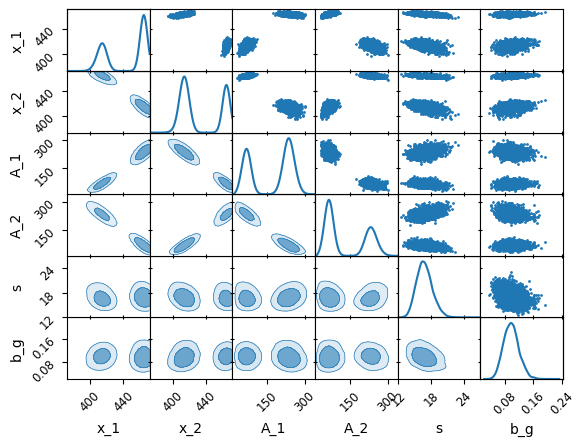

In [30]:
# Triangle plot (from anesthetic) to have a look to all parameters at the same time
an.triangle_plot(['x_1', 'x_2', 'A_1', 'A_2','s','b_g'])

In [31]:
# Statistics (from anesthetic) to have a good estimation of the uncertainties (expecially for the evidence)
an.stats()

/home/dph/nested_fit/venv/lib/python3.12/site-packages/anesthetic/samples.py:1403: RuntimeWarning: 25 out of 29167 samples have logL <= logL_birth,
25 of which have logL == logL_birth.
This may just indicate numerical rounding errors at the peak of the likelihood, but further investigation of the chains files is recommended.
Dropping the invalid samples.
  warnings.warn(


logZ 	 = -324.531557 	± 0.121622
D_KL 	 = 13.614484 	± 0.118992
logL_P 	 = -310.917073 	± 0.045302
d_G 	 = 6.128513 	± 0.151868


## Three Gaussian plus background

In [32]:
# Define a directory 
path = root_path+'/res_3gauss_bg'
# Go to a define analysis
os.chdir(path)

print(path)

/home/dph/nested_fit/examples/jupyter_notebooks/res_3gauss_bg


### Run the code

In [33]:
# Define inputs using a "latex" function
conf = pynf.Configurator(
    datafiles=['he-histo.dat'], # Name of the data file
    filefmt='.tsv',             # Format of file (here for tab and space separated)
    specstr='x,c',              # Datafile layout (here ch. and counts in ch.)
    expressions=[               # Function expression in latex form using an internal function (twice)
        r'triple_gauss_bg(x, x_1, x_2, x_3, A_1, A_2, A_3, s, b_g) =' + 
        r' + \texttt{GAUSS_IF}(x, x_1, A_1, s)' +  # These additional "+" are to write in more than one line
        r' + \texttt{GAUSS_IF}(x, x_2, A_2, s)' + 
        r' + \texttt{GAUSS_IF}(x, x_3, A_3, s) + b_g'], 
    params={                    # function expression in latex form
        'b_g': {'value': 0.01,  'step': -1, 'min': 0,   'max': 0.3 },
        'x_1': {'value': 454.6, 'step': -1, 'min': 300, 'max': 600 },
        'x_2': {'value': 454.6, 'step': -1, 'min': 300, 'max': 600 },
        'x_3': {'value': 454.6, 'step': -1, 'min': 300, 'max': 600 },
        'A_1': {'value': 300,   'step': -1, 'min': 0,   'max': 500},
        'A_2': {'value': 300,   'step': -1, 'min': 0,   'max': 500},
        'A_3': {'value': 300,   'step': -1, 'min': 0,   'max': 500},
        's':   {'value': 20,    'step': -1, 'min': 10,  'max': 30}
    },
    data={'xmin': 250, 'xmax': 650},  # Boundaries of data
    livepoints=1000,                  # Number of live points
    search_method='SLICE_SAMPLING',   # Search method
    search_params=(0.5, 3),           # Parameters of chosen method
    search_maxsteps=100000,           # Max steps of nested sampling
    conv_accuracy=1.E-05,             # Evidence final accuracy
    # num_tries=4,                    # Number of run of the same analysis for error estimation
    cluster_enable=True,             # clustering recognition on/off
     cluster_method='g',             # method used
     cluster_parameter1=0.5,         # method parameter 1 (if needed)
     cluster_parameter2=0.2,         # method parameter 1 (if needed)
)

In [34]:
# Run the code

out = conf.sample(output_mode='none')

### Visualize the results 

In [57]:
# Load the nested output data
# The available parameters and other variables that can be plotted are listed
an=pynf.Analysis()

Current path =  .
Result file nf_output_energy.txt not present
 No energies data loaded
['x_1', 'x_2', 'x_3', 'x_4', 'A_1', 'A_2', 'A_3', 'A_4', 's', 'b_g']
Index(['weight', 'lnlikelihood', 'x_1', 'x_2', 'x_3', 'x_4', 'A_1', 'A_2',
       'A_3', 'A_4', 's', 'b_g'],
      dtype='str')
Available parameters : ['weight', 'lnlikelihood', 'x_1', 'x_2', 'x_3', 'x_4', 'A_1', 'A_2', 'A_3', 'A_4', 's', 'b_g']


0 max
nf_output_data_max.dat


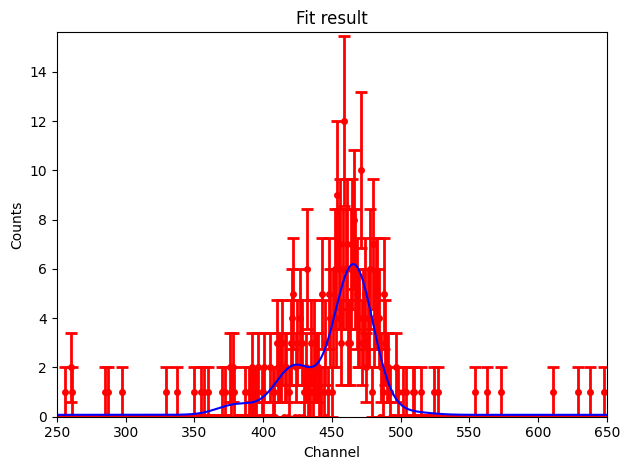

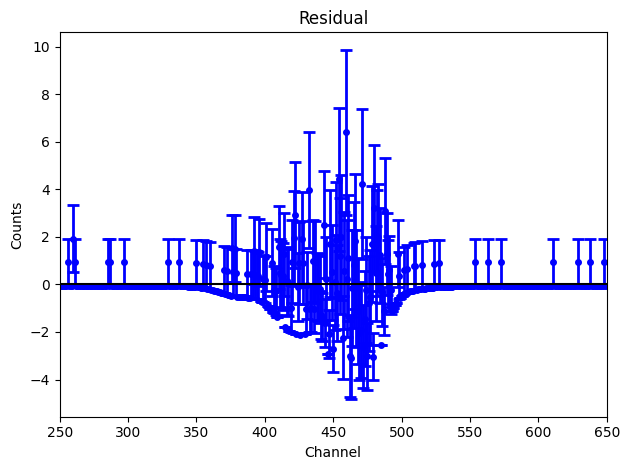

In [58]:
# Plot the data with the best fit (parameters corresponding to the maximum value of the data) and residual
# Other choices are median and mean parameters values selectable with "typeof='mean'" and "typeof='median'"
an.plot()

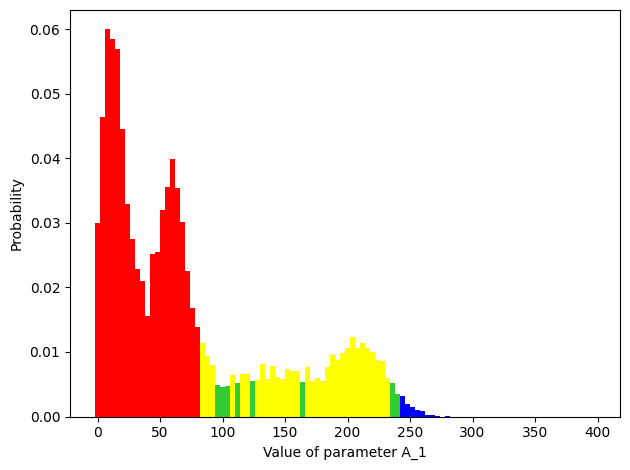

In [59]:
# Plot one parameter histogram
# Red, yellow and green region correspond to 1,2,3 sigmas
an.histo('A_1',bins=100,xmin=0,xmax=400)

/home/dph/nested_fit/venv/lib/python3.12/site-packages/pynested_fit/nested_res.py:1177: RuntimeWarning: divide by zero encountered in log
  plt.imshow(log(histo2D_data68[::-1,]),interpolation='nearest',extent=extent,aspect='auto',cmap=rvb68)
/home/dph/nested_fit/venv/lib/python3.12/site-packages/pynested_fit/nested_res.py:1178: RuntimeWarning: divide by zero encountered in log
  plt.imshow(log(histo2D_data95[::-1,]),interpolation='nearest',extent=extent,aspect='auto',cmap=rvb95)
/home/dph/nested_fit/venv/lib/python3.12/site-packages/pynested_fit/nested_res.py:1179: RuntimeWarning: divide by zero encountered in log
  plt.imshow(log(histo2D_data99[::-1,]),interpolation='nearest',extent=extent,aspect='auto',cmap=rvb99)
/home/dph/nested_fit/venv/lib/python3.12/site-packages/pynested_fit/nested_res.py:1180: RuntimeWarning: divide by zero encountered in log
  plt.imshow(log(histo2D_data_rest[::-1,]),interpolation='nearest',extent=extent,aspect='auto',cmap=rvb_rest)


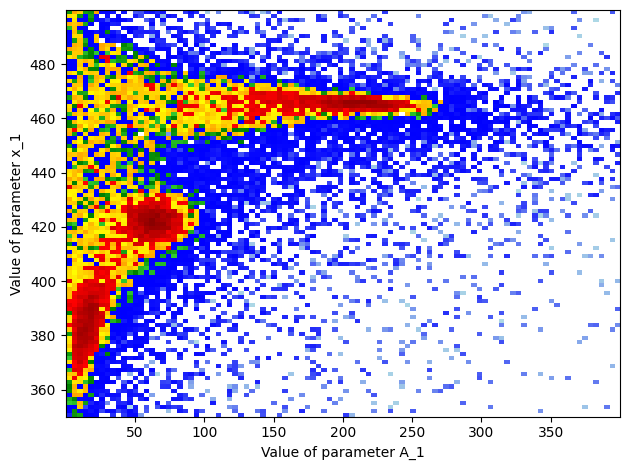

In [60]:
# Plot one parameter histogram
# Red, yellow and green region correspond to 1,2,3 sigmas
an.histo2D('A_1','x_1',bins=100,xmin=0,xmax=400,ymin=350,ymax=500)

/home/dph/nested_fit/venv/lib/python3.12/site-packages/anesthetic/samples.py:1403: RuntimeWarning: 46 out of 36819 samples have logL <= logL_birth,
46 of which have logL == logL_birth.
This may just indicate numerical rounding errors at the peak of the likelihood, but further investigation of the chains files is recommended.
Dropping the invalid samples.
  warnings.warn(


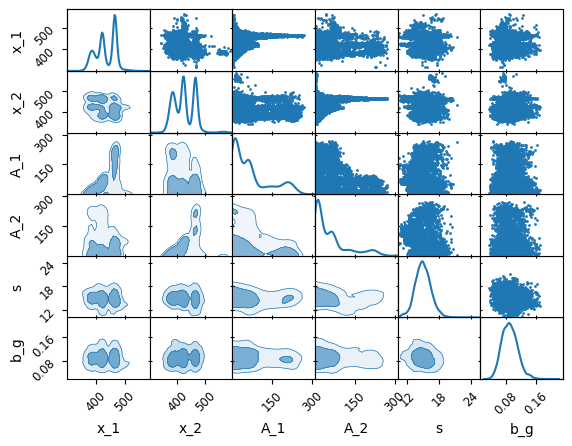

In [61]:
# Triangle plot (from anesthetic) to have a look to all parameters at the same time
an.triangle_plot(['x_1', 'x_2', 'A_1', 'A_2','s','b_g'])

In [62]:
# Statistics (from anesthetic) to have a good estimation of the uncertainties (expecially for the evidence)
an.stats()

/home/dph/nested_fit/venv/lib/python3.12/site-packages/anesthetic/samples.py:1403: RuntimeWarning: 46 out of 36819 samples have logL <= logL_birth,
46 of which have logL == logL_birth.
This may just indicate numerical rounding errors at the peak of the likelihood, but further investigation of the chains files is recommended.
Dropping the invalid samples.
  warnings.warn(


logZ 	 = -326.687216 	± 0.138386
D_KL 	 = 19.058771 	± 0.121557
logL_P 	 = -307.628445 	± 0.063346
d_G 	 = 11.413166 	± 0.289567


In [63]:
# If a cluster analysis have been done, visualize the clusters
## in 2D
an.plot_clusters('x_1','x_2')

Taking the last available file


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:3                                                                                    │
│                                                                                                  │
│   1 # If a cluster analysis have been done, visualize the clusters                               │
│   2 ## in 2D                                                                                     │
│ ❱ 3 an.plot_clusters('x_1','x_2')                                                                │
│   4                                                                                              │
│                                                                                                  │
│ /home/dph/nested_fit/venv/lib/python3.12/site-packages/pynested_fit/nested_res.py:921 in         │
│ plot_clusters                                                                                    │
│                                                                                                  │
│    918 │   │   if label == None:                                                                 │
│    919 │   │   │   available_files = sorted(glob.glob('nf_output_cluster_final_*.dat'))          │
│    920 │   │   │   print('Taking the last available file')                                       │
│ ❱  921 │   │   │   parts = available_files[-1].split('_')                                        │
│    922 │   │   │   label = parts[4] + '_' + parts[5].split('.')[0]                               │
│    923                                                                                           │
│    924                                                                                           │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
IndexError: list index out of range

In [ ]:
## and in 3D
an.plot_clusters3D('x_1','x_2','x_3')

## Four Gaussian plus background

In [44]:
# Define a directory 
path = root_path+'/res_4gauss_bg'
# Go to a define analysis
os.chdir(path)

print(path)

/home/dph/nested_fit/examples/jupyter_notebooks/res_4gauss_bg


### Run the code

In [45]:
# Define inputs using a "latex" function
conf = pynf.Configurator(
    datafiles=['he-histo.dat'], # Name of the data file
    filefmt='.tsv',             # Format of file (here for tab and space separated)
    specstr='x,c',              # Datafile layout (here ch. and counts in ch.)
    expressions=[               # Function expression in latex form using an internal function (twice)
        r'four_gauss_bg(x, x_1, x_2, x_3, x_4, A_1, A_2, A_3, A_4, s, b_g) =' + 
        r' + \texttt{GAUSS_IF}(x, x_1, A_1, s)' +  # These additional "+" are to write in more than one line
        r' + \texttt{GAUSS_IF}(x, x_2, A_2, s)' + 
        r' + \texttt{GAUSS_IF}(x, x_3, A_3, s)' + 
        r' + \texttt{GAUSS_IF}(x, x_4, A_4, s) + b_g'], 
    params={                    # function expression in latex form
        'b_g': {'value': 0.01,  'step': -1, 'min': 0,   'max': 0.3 },
        'x_1': {'value': 454.6, 'step': -1, 'min': 300, 'max': 600 },
        'x_2': {'value': 454.6, 'step': -1, 'min': 300, 'max': 600 },
        'x_3': {'value': 454.6, 'step': -1, 'min': 300, 'max': 600 },
        'x_4': {'value': 454.6, 'step': -1, 'min': 300, 'max': 600 },
        'A_1': {'value': 300,   'step': -1, 'min': 0,   'max': 500},
        'A_2': {'value': 300,   'step': -1, 'min': 0,   'max': 500},
        'A_3': {'value': 300,   'step': -1, 'min': 0,   'max': 500},
        'A_4': {'value': 300,   'step': -1, 'min': 0,   'max': 500},
        's':   {'value': 20,    'step': -1, 'min': 10,  'max': 30}
    },
    data={'xmin': 250, 'xmax': 650},  # Boundaries of data
    livepoints=1000,                  # Number of live points
    search_method='SLICE_SAMPLING',   # Search method
    search_params=(0.5, 3),           # Parameters of chosen method
    search_maxsteps=100000,           # Max steps of nested sampling
    conv_accuracy=1.E-05,             # Evidence final accuracy
    # num_tries=4,                    # Number of run of the same analysis for error estimation
    cluster_enable=True,              # clustering recognition on/off
    # cluster_method='k',             # method used
    # cluster_parameter1=0.5,         # method parameter 1 (if needed)
    # cluster_parameter2=0.2,         # method parameter 1 (if needed)
)

In [46]:
# Run the code

out = conf.sample(output_mode='none')

### Visualize the results 

In [47]:
# Load the nested output data
# The available parameters and other variables that can be plotted are listed
an=pynf.Analysis()

Current path =  .
Result file nf_output_energy.txt not present
 No energies data loaded
['x_1', 'x_2', 'x_3', 'x_4', 'A_1', 'A_2', 'A_3', 'A_4', 's', 'b_g']
Index(['weight', 'lnlikelihood', 'x_1', 'x_2', 'x_3', 'x_4', 'A_1', 'A_2',
       'A_3', 'A_4', 's', 'b_g'],
      dtype='str')
Available parameters : ['weight', 'lnlikelihood', 'x_1', 'x_2', 'x_3', 'x_4', 'A_1', 'A_2', 'A_3', 'A_4', 's', 'b_g']


0 max
nf_output_data_max.dat


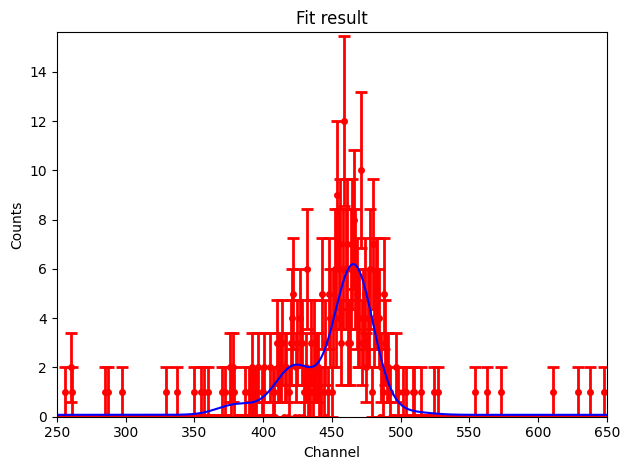

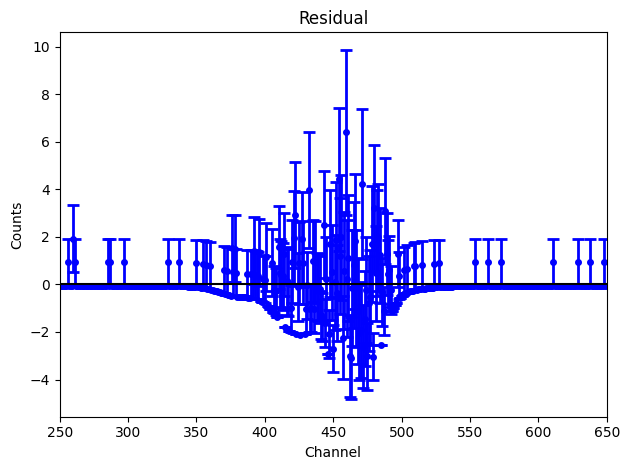

In [48]:
# Plot the data with the best fit (parameters corresponding to the maximum value of the data) and residual
# Other choices are median and mean parameters values selectable with "typeof='mean'" and "typeof='median'"
an.plot()

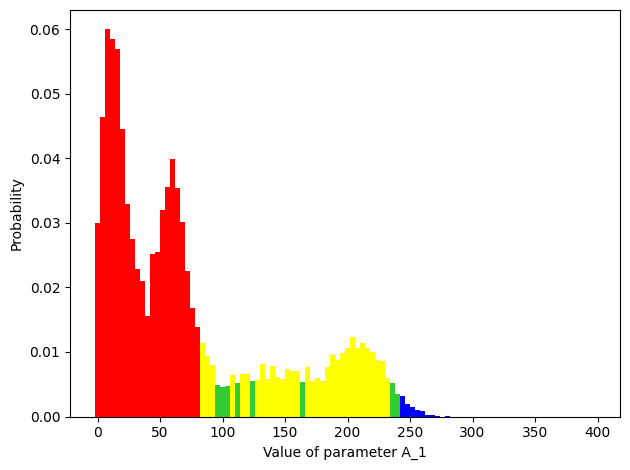

In [49]:
# Plot one parameter histogram
# Red, yellow and green region correspond to 1,2,3 sigmas
an.histo('A_1',bins=100,xmin=0,xmax=400)

/home/dph/nested_fit/venv/lib/python3.12/site-packages/pynested_fit/nested_res.py:1177: RuntimeWarning: divide by zero encountered in log
  plt.imshow(log(histo2D_data68[::-1,]),interpolation='nearest',extent=extent,aspect='auto',cmap=rvb68)
/home/dph/nested_fit/venv/lib/python3.12/site-packages/pynested_fit/nested_res.py:1178: RuntimeWarning: divide by zero encountered in log
  plt.imshow(log(histo2D_data95[::-1,]),interpolation='nearest',extent=extent,aspect='auto',cmap=rvb95)
/home/dph/nested_fit/venv/lib/python3.12/site-packages/pynested_fit/nested_res.py:1179: RuntimeWarning: divide by zero encountered in log
  plt.imshow(log(histo2D_data99[::-1,]),interpolation='nearest',extent=extent,aspect='auto',cmap=rvb99)
/home/dph/nested_fit/venv/lib/python3.12/site-packages/pynested_fit/nested_res.py:1180: RuntimeWarning: divide by zero encountered in log
  plt.imshow(log(histo2D_data_rest[::-1,]),interpolation='nearest',extent=extent,aspect='auto',cmap=rvb_rest)


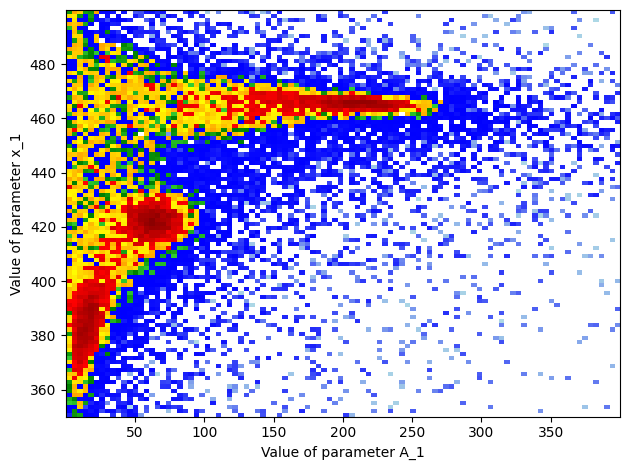

In [50]:
# Plot one parameter histogram
# Red, yellow and green region correspond to 1,2,3 sigmas
an.histo2D('A_1','x_1',bins=100,xmin=0,xmax=400,ymin=350,ymax=500)

/home/dph/nested_fit/venv/lib/python3.12/site-packages/anesthetic/samples.py:1403: RuntimeWarning: 46 out of 36819 samples have logL <= logL_birth,
46 of which have logL == logL_birth.
This may just indicate numerical rounding errors at the peak of the likelihood, but further investigation of the chains files is recommended.
Dropping the invalid samples.
  warnings.warn(


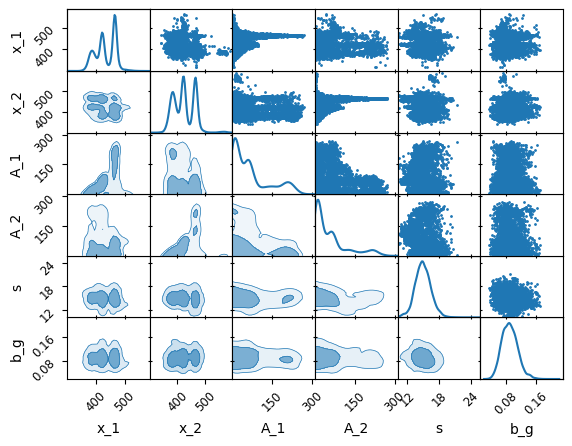

In [51]:
# Triangle plot (from anesthetic) to have a look to all parameters at the same time
an.triangle_plot(['x_1', 'x_2', 'A_1', 'A_2','s','b_g'])

In [52]:
# Statistics (from anesthetic) to have a good estimation of the uncertainties (expecially for the evidence)
an.stats()

/home/dph/nested_fit/venv/lib/python3.12/site-packages/anesthetic/samples.py:1403: RuntimeWarning: 46 out of 36819 samples have logL <= logL_birth,
46 of which have logL == logL_birth.
This may just indicate numerical rounding errors at the peak of the likelihood, but further investigation of the chains files is recommended.
Dropping the invalid samples.
  warnings.warn(


logZ 	 = -326.700062 	± 0.152981
D_KL 	 = 19.055450 	± 0.144618
logL_P 	 = -307.644612 	± 0.067483
d_G 	 = 11.428404 	± 0.248160
